In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### Read the Data

In [3]:
test_data=pd.read_csv("test_lAUu6dG.csv")
df=test_data.copy()

In [4]:
df['Loan_ID']

0      LP001015
1      LP001022
2      LP001031
3      LP001035
4      LP001051
         ...   
362    LP002971
363    LP002975
364    LP002980
365    LP002986
366    LP002989
Name: Loan_ID, Length: 367, dtype: object

In [5]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

In [6]:
cat=df.select_dtypes(include='object').columns
num=df.select_dtypes(exclude='object').columns
num

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [9]:
df.shape

(367, 12)

In [16]:
df.duplicated().sum()

0

### Missing values Analysis 

In [19]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [21]:
df['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [23]:
gender_mode=df['Gender'].mode()
df['Gender'].fillna(gender_mode[0],axis=0,inplace=True)

In [25]:
Married_mode=df['Married'].mode()[0]
df['Married'].fillna(Married_mode,inplace=True)

In [27]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [29]:
df['Dependents']=df['Dependents'].fillna(method='bfill')

In [31]:
self_emp_mode=df['Self_Employed'].mode()[0]
df['Self_Employed']=df['Self_Employed'].fillna(self_emp_mode)
# ================================================================
Loan_amount_med=df['LoanAmount'].median()
df['LoanAmount']=df['LoanAmount'].fillna(Loan_amount_med)
# ================================================================
Loan_Amount_Term_med=df['Loan_Amount_Term'].median()
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(Loan_Amount_Term_med)
# ================================================================
Credit_hitory_mode=df['Credit_History'].mode()[0]
df['Credit_History']=df['Credit_History'].fillna(Credit_hitory_mode)

In [33]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [35]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

**Dtypes**

In [38]:
df['Dependents'] = df['Dependents'].str.replace('+', '', regex=False)

In [40]:
df['CoapplicantIncome']=df['CoapplicantIncome'].astype('int')
df['LoanAmount']=df['LoanAmount'].astype('int')
df['Loan_Amount_Term']=df['Loan_Amount_Term'].astype('int')
df['Credit_History']=df['Credit_History'].astype('int')
df['Dependents']=df['Dependents'].astype('int')
df['ApplicantIncome']=df['ApplicantIncome'].astype('int')

In [42]:
df.dtypes

Loan_ID              object
Gender               object
Married              object
Dependents            int32
Education            object
Self_Employed        object
ApplicantIncome       int32
CoapplicantIncome     int32
LoanAmount            int32
Loan_Amount_Term      int32
Credit_History        int32
Property_Area        object
dtype: object

In [44]:
df.drop('Loan_ID',axis=1,inplace=True)

### Outliers Analysis

In [47]:
def outliers_handling(column_name):
    q1=np.percentile(df[column_name],25)
    q2=np.percentile(df[column_name],50)
    q3=np.percentile(df[column_name],75)
    IQR=q3-q1
    lb=q1-1.5*IQR
    ub=q3+1.5*IQR
    # ======================================================================================
    cond= (df[column_name]<lb) | (df[column_name]>ub)
    true=df[column_name].median()
    false=df[column_name]
    df[column_name]=np.where(cond,true,false)
    return df[column_name]
def outliers_len(column_name):
    q1=np.percentile(df[column_name],25)
    q2=np.percentile(df[column_name],50)
    q3=np.percentile(df[column_name],75)
    IQR=q3-q1
    lb=q1-1.5*IQR
    ub=q3+1.5*IQR
    cond= (df[column_name]<lb) | (df[column_name]>ub)
    outliers_df=df[[column_name]][cond]
    # len(outliers_df)
    print(f"The length of the outliers is : {len(outliers_df)}")

In [49]:
def box_plot(colum_name):
    plt.figure(figsize=(10,5))
    df[colum_name].plot(kind='box',vert=False)
    plt.title(f"{colum_name} Box plot")
    plt.show()

**ApplicantIncome**

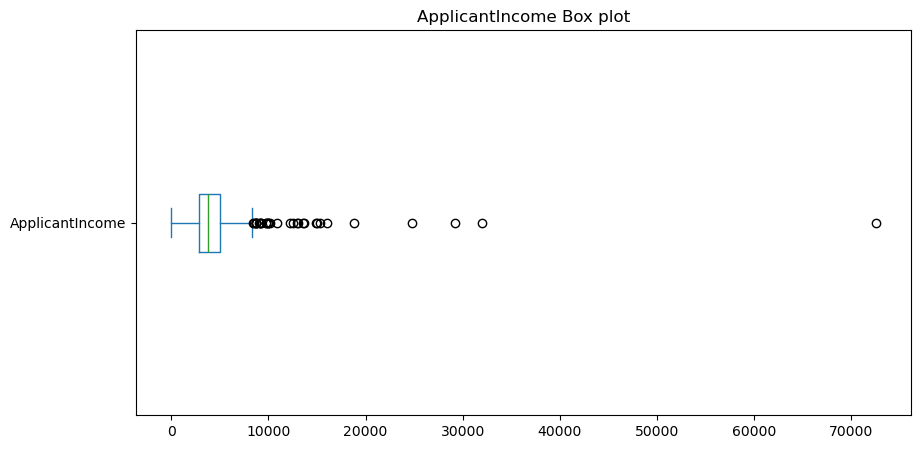

The length of the outliers is : 32


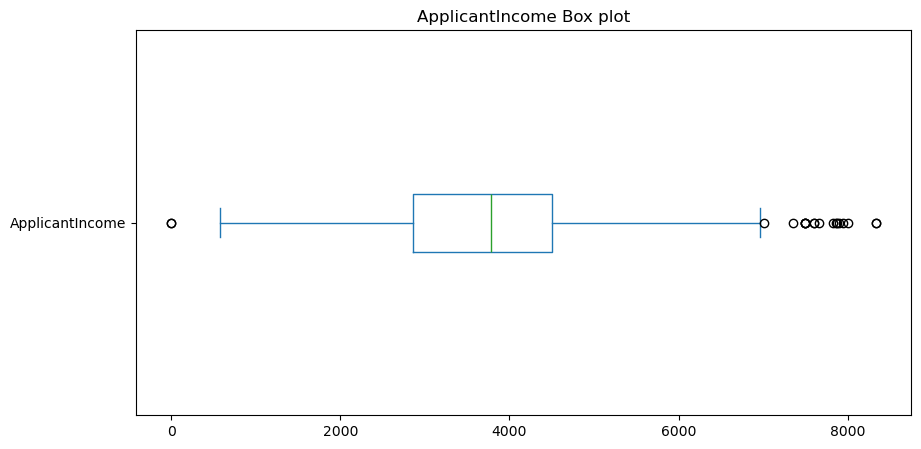

In [52]:
box=box_plot('ApplicantIncome')
outliers_len('ApplicantIncome')
outliers_handling('ApplicantIncome')
box=box_plot('ApplicantIncome')

**CoapplicantIncome**

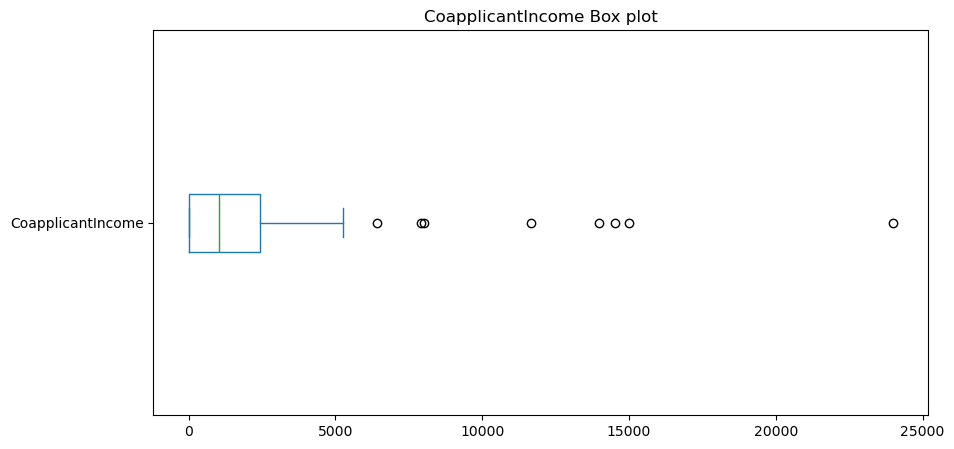

The length of the outliers is : 0


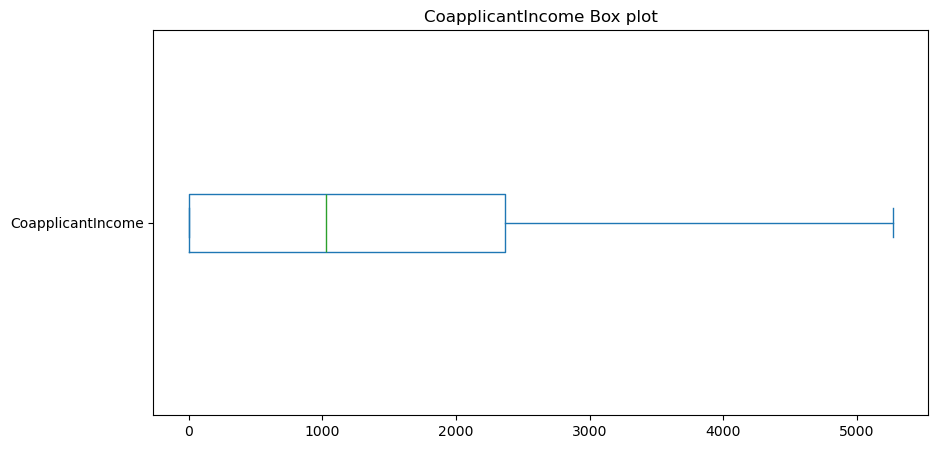

In [55]:
box=box_plot('CoapplicantIncome')
outliers_handling('CoapplicantIncome')
outliers_len('CoapplicantIncome')
box_plot('CoapplicantIncome')

**ApplicantIncome**

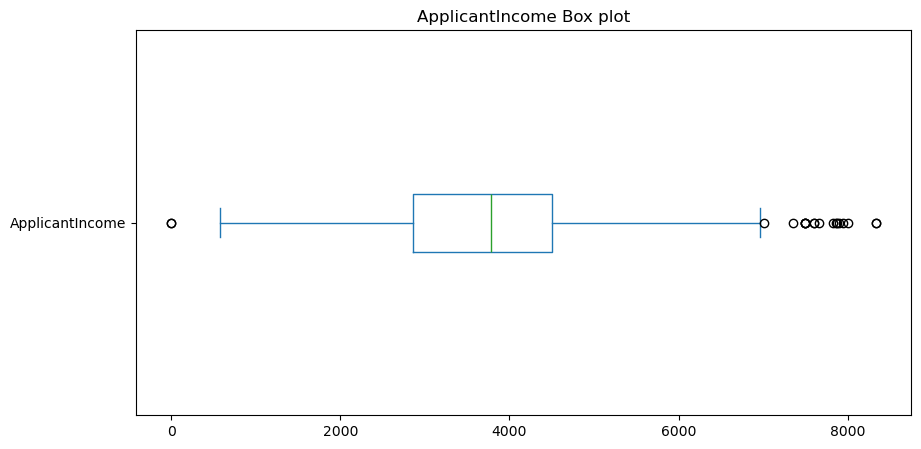

The length of the outliers is : 19


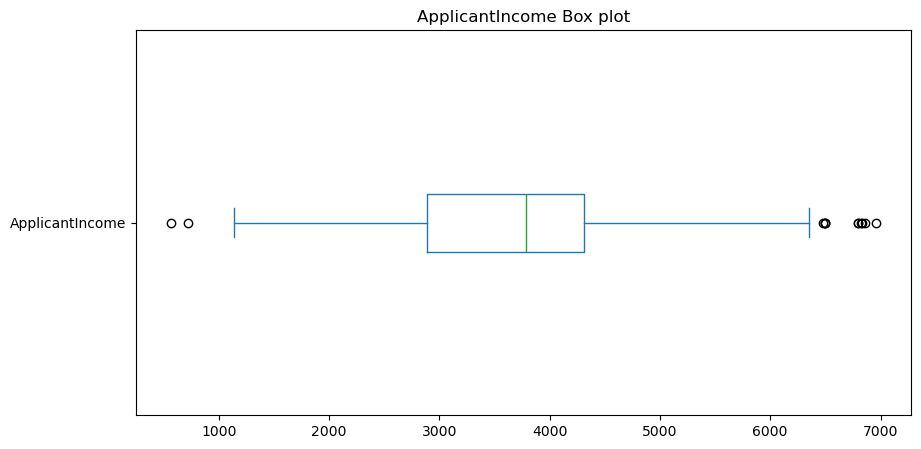

In [58]:
box=box_plot('ApplicantIncome')
outliers_len('ApplicantIncome')
outliers_handling('ApplicantIncome')
box=box_plot('ApplicantIncome')

<Axes: ylabel='Frequency'>

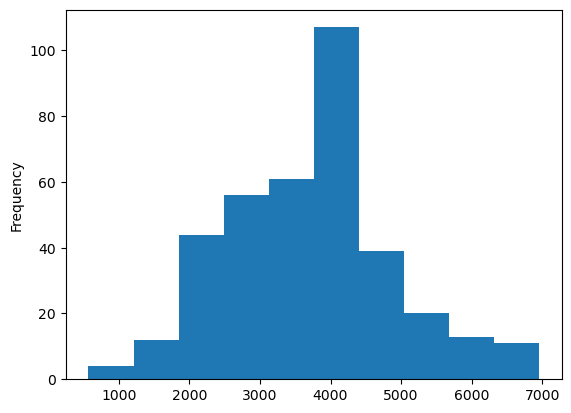

In [59]:
df['ApplicantIncome'].plot(kind='hist')

**Loan Amount**

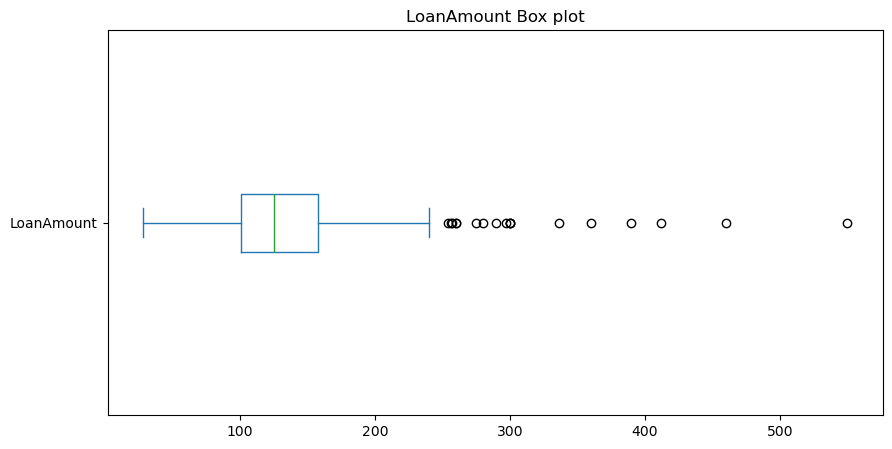

The length of the outliers is : 12


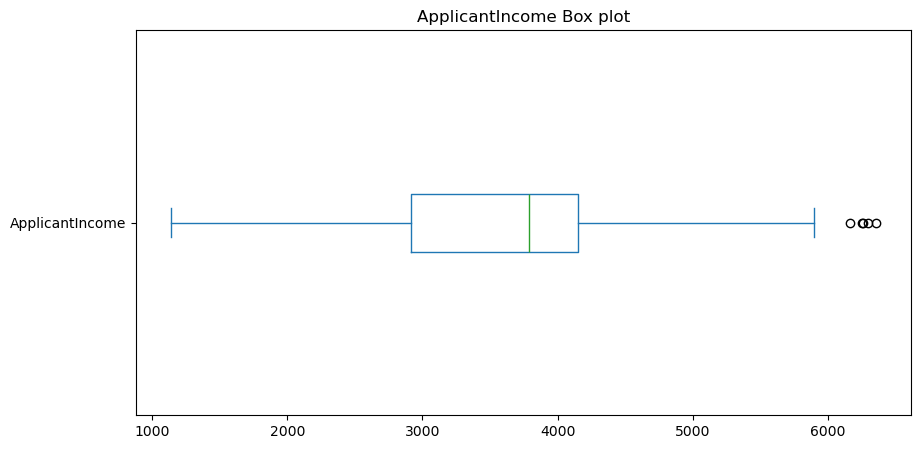

In [63]:
box=box_plot('LoanAmount')
outliers_handling('LoanAmount')
outliers_len('ApplicantIncome')
outliers_handling('ApplicantIncome')
box=box_plot('ApplicantIncome')

### Encoding

In [66]:
cat=df.select_dtypes(include='object').columns
cat.drop('Property_Area')


Index(['Gender', 'Married', 'Education', 'Self_Employed'], dtype='object')

In [68]:
cat

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], dtype='object')

In [70]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
for i in cat:
    LE=LabelEncoder()
    df[i]=LE.fit_transform(df[i])


In [72]:
oe = OneHotEncoder(sparse_output=False)  # or sparse=False for older sklearn versions
df['Property_Area'] = oe.fit_transform(df[['Property_Area']])

In [74]:
df['Property_Area'] =df['Property_Area'].astype('int')


In [76]:
df['CoapplicantIncome']=df['CoapplicantIncome'].astype('int')
df['LoanAmount']=df['LoanAmount'].astype('int')
df['Loan_Amount_Term']=df['Loan_Amount_Term'].astype('int')
df['Credit_History']=df['Credit_History'].astype('int')
df['Dependents']=df['Dependents'].astype('int')
df['ApplicantIncome']=df['ApplicantIncome'].astype('int')

In [78]:
df.dtypes

Gender               int32
Married              int32
Dependents           int32
Education            int32
Self_Employed        int32
ApplicantIncome      int32
CoapplicantIncome    int32
LoanAmount           int32
Loan_Amount_Term     int32
Credit_History       int32
Property_Area        int32
dtype: object

In [80]:
Encode_Data=df.copy()
Encode_Data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110,360,1,0
1,1,1,1,0,0,3076,1500,126,360,1,0
2,1,1,2,0,0,5000,1800,208,360,1,0
3,1,1,2,0,0,2340,2546,100,360,1,0
4,1,0,0,1,0,3276,0,78,360,1,0
...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,3,1,1,4009,1777,113,360,1,0
363,1,1,0,0,0,4158,709,115,360,1,0
364,1,0,0,0,0,3250,1993,126,360,1,0
365,1,1,0,0,0,5000,2393,158,360,1,1


**Scaling**

In [83]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [85]:
# df.columns
SS=StandardScaler()

In [87]:
scalable_data=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term',]
for i in scalable_data:
    df[i]=SS.fit_transform(df[[i]])

In [89]:
df['CoapplicantIncome']=df['CoapplicantIncome'].astype('int')
df['LoanAmount']=df['LoanAmount'].astype('int')
df['Loan_Amount_Term']=df['Loan_Amount_Term'].astype('int')
df['Credit_History']=df['Credit_History'].astype('int')
df['Dependents']=df['Dependents'].astype('int')
df['ApplicantIncome']=df['ApplicantIncome'].astype('int')

In [91]:
Scaled_data=df.copy()
Scaled_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,2,0,0,0,1,0
1,1,1,1,0,0,0,0,0,0,1,0
2,1,1,2,0,0,1,0,2,0,1,0
3,1,1,2,0,0,-1,0,0,0,1,0
4,1,0,0,1,0,0,0,-1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,3,1,1,0,0,0,0,1,0
363,1,1,0,0,0,0,0,0,0,1,0
364,1,0,0,0,0,0,0,0,0,1,0
365,1,1,0,0,0,1,0,0,0,1,1


**PCA**

In [107]:
# X=df.drop("Loan_Status",axis=1)

In [110]:
from sklearn.decomposition import PCA
pca=PCA(n_components=10)
pca

PCA(n_components=10)

In [112]:
pca_data=pca.fit_transform(df)


In [116]:
pca_data=pd.DataFrame(pca_data,columns=['PCA1','PCA2','PCA3','PCA4','PCA5','PCA6','PCA7','PCA8','PCA9','PCA10'])
pca_data

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10
0,-0.588776,0.459489,1.693392,-1.072926,0.257528,0.347027,-0.529340,0.102431,-0.128399,-0.163804
1,0.222010,0.174512,-0.042245,-0.133591,-0.103603,0.258519,-0.445546,-0.271383,0.036585,0.068607
2,1.360418,1.074986,1.549251,0.839790,-0.634844,0.018277,-0.338426,-0.105003,0.141511,0.099752
3,1.113080,0.058256,-0.965299,0.326289,-0.279354,0.130679,-0.366999,-0.477631,0.135467,0.220674
4,-0.926045,-0.276851,-0.534194,-0.997410,-0.139995,-0.065270,0.013425,0.778672,0.115910,0.322213
...,...,...,...,...,...,...,...,...,...,...
362,2.207490,0.307767,-0.372001,-0.172688,-0.252328,0.220762,-0.004720,0.554651,0.448169,0.160196
363,-0.749345,0.122048,0.068228,-0.114016,-0.113231,0.425691,-0.518845,-0.232701,0.003807,-0.003117
364,-0.929158,0.045646,0.076971,-0.208319,-0.280740,-0.299987,-0.171287,-0.090972,0.069746,0.498832
365,-0.689123,0.300405,0.923390,-0.504571,0.363355,0.663405,0.351728,-0.266544,-0.028749,-0.137619


In [115]:
# pca_data['Loan_Status']=df['Loan_Status']
# pca_data

In [118]:
# PCA_data=df.copy()
PCA_data=pca_data.copy()
PCA_data.to_csv("preprocessed_test_data.csv", index=False)